# CAPTCHA Patch Selection — Data Annotation Exercise

## Context
Image-based CAPTCHAs are not just security mechanisms — they are large-scale **crowdsourced data collection systems**. When you solve a CAPTCHA by clicking "select all traffic lights", you are producing labeled training data for object detectors. This is the exact pipeline that powered early autonomous-driving perception datasets.

## Learning Objectives
After completing this exercise you will be able to:
1. Explain how crowdsourced CAPTCHA responses produce image annotation data.
2. Describe why *many* annotations are needed to produce a reliable result (noise vs. consensus).
3. Connect patch-level binary labels to **semantic segmentation** and **bounding box detection** — two core tasks in embodied AI perception pipelines.
4. Interpret an accumulated heatmap as a probability estimate for object presence.
5. Compare a sparse, hand-collected result with a simulated large-scale dataset result.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import io
import random
import json
from pathlib import Path

random.seed(42)   # fixed seed → reproducible patch positions across runs


## Load Image & Initialize State
We load the target image and initialize the heatmap accumulator.

In [2]:
# Configuration
NOTEBOOK_DIR = Path().resolve()          # assumes CWD = notebooks/ (Jupyter default)
IMAGE_PATH   = NOTEBOOK_DIR / 'verkehr.jpg'
PATCH_SIZE   = (150, 150)                # smaller patches → finer heatmap resolution
GRID_DIMS    = (3, 3)

# Load Image
full_image    = Image.open(IMAGE_PATH).convert('RGB')
full_image    = full_image.resize((1200, 800))
full_image_np = np.array(full_image)
print(f"Loaded image: {IMAGE_PATH.name} with shape {full_image_np.shape}")

# Initialize Heatmap (same H×W as image, single channel)
heatmap      = np.zeros(full_image_np.shape[:2], dtype=np.float32)
rounds_played = 0


Loaded image: verkehr.jpg with shape (800, 1200, 3)


## Helper Functions
Functions to extract patches, convert images for widgets, and generate the heatmap overlay.

In [3]:
def get_random_patch(image_np, size=(100, 100)):
    """Extracts a random patch from the image."""
    h, w, _ = image_np.shape
    ph, pw = size
    if h < ph or w < pw:
        return np.zeros((ph, pw, 3), dtype=np.uint8), 0, 0
    x = random.randint(0, w - pw)
    y = random.randint(0, h - ph)
    return image_np[y:y+ph, x:x+pw], x, y


def np_to_b64(img_np):
    """Converts a numpy image array to PNG bytes for display in ipywidgets."""
    buf = io.BytesIO()
    Image.fromarray(img_np).save(buf, format='PNG')
    return buf.getvalue()


def overlay_heatmap(img_np, heatmap):
    """Overlays the accumulated heatmap on the original image using the plasma colormap."""
    max_val = np.max(heatmap)
    norm_heatmap = heatmap / max_val if max_val > 0 else heatmap

    # plasma is perceptually uniform and colorblind-friendly (unlike jet)
    heatmap_colored = (plt.cm.plasma(norm_heatmap)[:, :, :3] * 255).astype(np.uint8)

    alpha   = 0.45
    overlay = (img_np * (1 - alpha) + heatmap_colored * alpha).astype(np.uint8)
    # keep original pixels where no selection has been made
    overlay[norm_heatmap == 0] = img_np[norm_heatmap == 0]
    return overlay


## Interactive Annotation Interface

Run the cell below to start the CAPTCHA simulation.

1. **Choose a class** from the dropdown (Traffic Lights / Cars / Traffic Signs).
2. **Select** the patches that match that class — click the checkbox below each patch.
3. Click **Proceed / Next Grid** to submit your selection and load a fresh set of patches.
4. Watch the **Accumulated Heatmap** build up below — it shows which regions of the image you marked most often.

After several rounds, scroll down to compare your sparse result with a **simulated 1000-round result**.


In [4]:
CLASS_LABELS = {
    "Traffic Lights": "traffic_light",
    "Cars":           "car",
    "Traffic Signs":  "traffic_sign",
}

# --- UI Elements ---
grid_container   = widgets.VBox()
img_heatmap      = widgets.Image(format='png')
lbl_heatmap_title = widgets.HTML()

btn_proceed = widgets.Button(
    description="Proceed / Next Grid",
    button_style='success',
    layout=widgets.Layout(width='210px', margin='20px 0px 0px 0px')
)
dropdown_class = widgets.Dropdown(
    options=list(CLASS_LABELS.keys()),
    value="Traffic Lights",
    description="Find:",
    layout=widgets.Layout(width='320px')
)
lbl_info = widgets.HTML(
    value="<h3>CAPTCHA Prompt: Select all patches containing <b>Traffic Lights</b></h3>"
)

def on_class_change(change):
    lbl_info.value = (
        f"<h3>CAPTCHA Prompt: Select all patches containing <b>{change['new']}</b></h3>"
    )
dropdown_class.observe(on_class_change, names='value')

# --- State ---
current_patches_coords = []
img_widgets            = []
checkboxes             = []


def generate_grid():
    global current_patches_coords, img_widgets, checkboxes
    current_patches_coords = []
    n_patches = GRID_DIMS[0] * GRID_DIMS[1]

    if not img_widgets:
        for _ in range(n_patches):
            iw  = widgets.Image(format='png', width=PATCH_SIZE[1], height=PATCH_SIZE[0])
            chk = widgets.Checkbox(value=False, description='Select', indent=False)
            img_widgets.append(iw)
            checkboxes.append(chk)

    for i in range(n_patches):
        patch, x, y = get_random_patch(full_image_np, PATCH_SIZE)
        current_patches_coords.append((x, y))
        img_widgets[i].value = np_to_b64(patch)
        checkboxes[i].value  = False

    rows = []
    for i in range(GRID_DIMS[0]):
        row_items = []
        for j in range(GRID_DIMS[1]):
            idx = i * GRID_DIMS[1] + j
            cell = widgets.VBox(
                [img_widgets[idx], checkboxes[idx]],
                layout=widgets.Layout(align_items='center', margin='5px')
            )
            row_items.append(cell)
        rows.append(widgets.HBox(row_items))
    grid_container.children = rows


def update_heatmap_display():
    buf = io.BytesIO()
    Image.fromarray(overlay_heatmap(full_image_np, heatmap)).save(buf, format='PNG')
    img_heatmap.value = buf.getvalue()


def on_proceed_clicked(b):
    global heatmap, rounds_played

    for i, chk in enumerate(checkboxes):
        if chk.value:
            x, y   = current_patches_coords[i]
            ph, pw = PATCH_SIZE
            heatmap[y:y+ph, x:x+pw] += 1.0

    rounds_played += 1          # count every round, not just rounds with selections
    generate_grid()
    lbl_heatmap_title.value = (
        f"<h3>Your Heatmap after {rounds_played} round(s) "
        f"— class: <em>{dropdown_class.value}</em></h3>"
    )
    update_heatmap_display()


btn_proceed.on_click(on_proceed_clicked)

# --- Initial display ---
generate_grid()
lbl_heatmap_title.value = f"<h3>Your Heatmap after {rounds_played} round(s)</h3>"
update_heatmap_display()

app_layout = widgets.VBox([
    lbl_info,
    dropdown_class,
    grid_container,
    btn_proceed,
    lbl_heatmap_title,
    img_heatmap,
])
display(app_layout)


## Ground Truth: Simulated 1000-Round Result

The cell below loads the ground-truth bounding box annotations for `verkehr.jpg` and **simulates what the heatmap would look like after 1 000 annotation rounds** — as if 1 000 users had each worked through one 3×3 grid.

A randomly sampled patch is counted as *selected* if its overlap with a ground-truth box of the chosen class exceeds a threshold (simulating an ideal, noise-free annotator).

**Compare the two outputs:**
- Does your sparse heatmap highlight the same regions as the simulated one?
- How many rounds did you need before your heatmap became meaningful?
- What do you notice about parts of the image that were *never* covered by any patch?


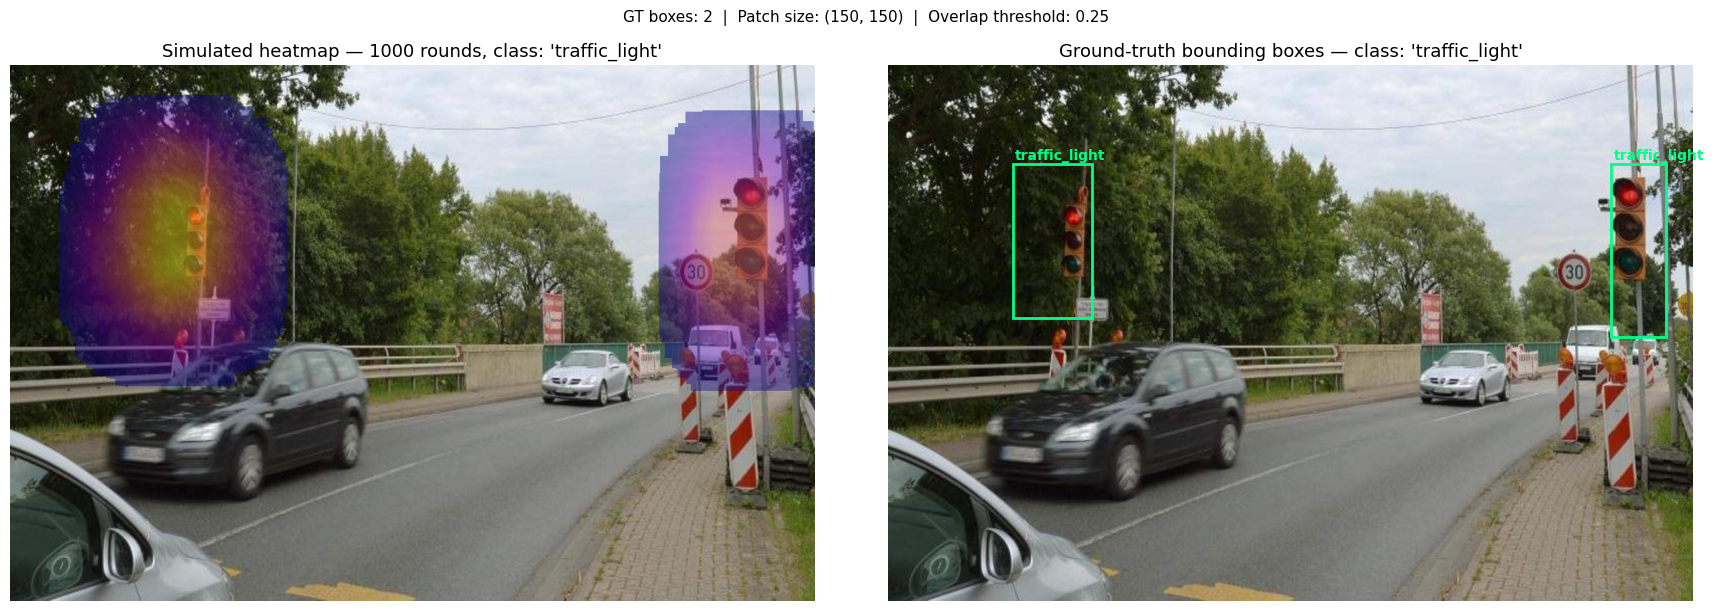

In [5]:
ANNOTATIONS_PATH = NOTEBOOK_DIR / 'annotations.json'

with open(ANNOTATIONS_PATH) as f:
    annotations = json.load(f)

# --- Configuration ---
SIMULATE_CLASS     = CLASS_LABELS[dropdown_class.value]  # matches whatever is selected above
N_ROUNDS           = 1000
N_PER_ROUND        = GRID_DIMS[0] * GRID_DIMS[1]
OVERLAP_THRESHOLD  = 0.25   # fraction of patch area that must overlap a GT box

gt_boxes = [obj["bbox"] for obj in annotations["objects"] if obj["label"] == SIMULATE_CLASS]
img_h, img_w = full_image_np.shape[:2]
ph, pw       = PATCH_SIZE

# --- Simulate N_ROUNDS rounds with an ideal (noise-free) annotator ---
sim_heatmap = np.zeros((img_h, img_w), dtype=np.float32)
rng = np.random.default_rng(seed=0)

for _ in range(N_ROUNDS):
    for _ in range(N_PER_ROUND):
        px = int(rng.integers(0, img_w - pw))
        py = int(rng.integers(0, img_h - ph))
        for (bx, by, bw, bh) in gt_boxes:
            ix1, iy1 = max(px, bx),      max(py, by)
            ix2, iy2 = min(px + pw, bx + bw), min(py + ph, by + bh)
            inter    = max(0, ix2 - ix1) * max(0, iy2 - iy1)
            if inter / (pw * ph) >= OVERLAP_THRESHOLD:
                sim_heatmap[py:py+ph, px:px+pw] += 1.0
                break   # count each patch once even if it overlaps multiple GT boxes

# --- Visualize side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(overlay_heatmap(full_image_np, sim_heatmap))
axes[0].set_title(
    f"Simulated heatmap — {N_ROUNDS} rounds, class: '{SIMULATE_CLASS}'", fontsize=13
)
axes[0].axis('off')

axes[1].imshow(full_image_np)
for obj in annotations["objects"]:
    if obj["label"] == SIMULATE_CLASS:
        bx, by, bw, bh = obj["bbox"]
        rect = plt.Rectangle((bx, by), bw, bh, linewidth=2,
                              edgecolor='#00FF88', facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(bx + 4, by - 6, obj["label"],
                     color='#00FF88', fontsize=10, fontweight='bold')
axes[1].set_title(
    f"Ground-truth bounding boxes — class: '{SIMULATE_CLASS}'", fontsize=13
)
axes[1].axis('off')

plt.suptitle(
    f"GT boxes: {len(gt_boxes)}  |  Patch size: {PATCH_SIZE}  |  "
    f"Overlap threshold: {OVERLAP_THRESHOLD}",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


## Reflection Questions

Answer these questions individually or in your group before the end of the session.

1. **From patches to segmentation** — The accumulated heatmap is a rough form of *semantic segmentation*. What information is lost compared to a proper pixel-level segmentation mask?

2. **Noise and consensus** — After only a few rounds, the heatmap is noisy. Why does it become more reliable with more annotations? Which statistical concept describes this convergence?

3. **Bias in patch sampling** — Patches are drawn uniformly at random from the image. Is this a good strategy? What could go wrong, and how might you sample more efficiently?

4. **From heatmap to bounding box** — Looking at the simulated heatmap, how could you *algorithmically* extract a bounding box from it? Think about thresholding and connected components.

5. **Real-world scale** — The reCAPTCHA system processes billions of responses per day. How does this change the quality, diversity, and potential biases of annotations compared to this small demo?

6. **Robot perception connection** — A Unitree Go2 robot needs to detect obstacles and traffic objects in real time. Which task from this exercise (patch selection, heatmap accumulation, bounding box detection) maps most directly to what its onboard vision pipeline must do?
